In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# EDA & Visualization
Analyzing raw market trends and correlations (outliers actively retained to capture true real-world volatility).

In [2]:
df = pd.read_csv('../data/processed/base_market_data.csv')

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume,Ticker_Name
0,2016-06-13,8110.600098,8125.250000,8063.899902,8102.250000,169700,^NSEI
1,2016-06-14,8108.850098,8134.950195,8069.500000,8134.399902,145500,^NSEI
2,2016-06-15,8206.599609,8213.200195,8123.149902,8139.399902,169800,^NSEI
3,2016-06-16,8140.750000,8180.649902,8074.450195,8180.649902,189200,^NSEI
4,2016-06-17,8170.200195,8195.250000,8135.799805,8176.649902,166600,^NSEI


In [4]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker_Name'], dtype='str')

In [5]:
df['Ticker_Name'].value_counts()

Ticker_Name
RELIANCE.NS    2471
HDFCBANK.NS    2471
TCS.NS         2471
INFY.NS        2471
ITC.NS         2471
LT.NS          2471
^NSEBANK       2464
^NSEI          2462
Name: count, dtype: int64

In [6]:
quantitative_columns = ['Close', 'High', 'Low', 'Open', 'Volume']

qualitative_column = 'Ticker_Name'

In [7]:
fig = px.pie(data_frame= df, names= qualitative_column)
fig.show()
fig.write_image('../assets/plots/dist_Ticker.png')


In [8]:
os.makedirs('../assets/plots', exist_ok=True)

for col in quantitative_columns:
    fig = px.histogram(data_frame=df, x=col, title=f"Distribution of {col}")
    fig.show()
    fig.write_image(f"../assets/plots/dist_{col}.png")

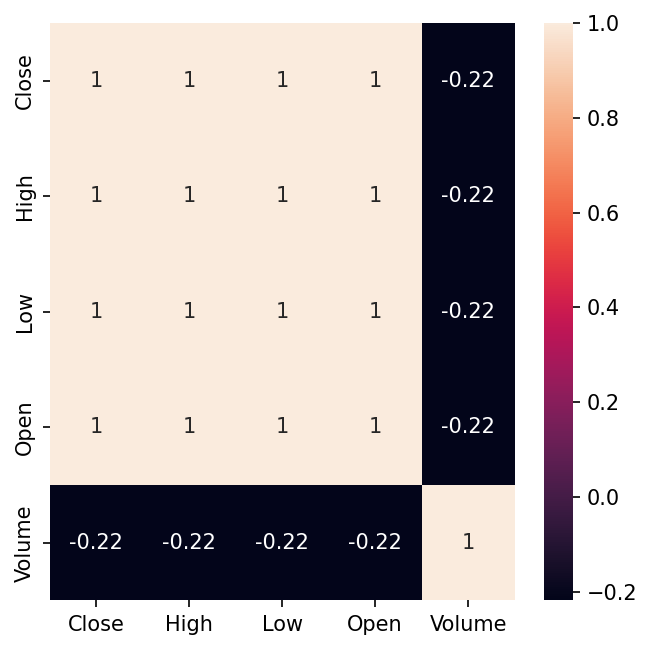

In [9]:
plt.figure(figsize= (5,5), dpi= 150)
sns.heatmap(df.corr(numeric_only= True), annot= True)
plt.savefig('../assets/plots/correlation_heatmap.png', bbox_inches='tight')